In [1]:

from lightning import Trainer
from torch.utils.flop_counter import FlopCounterMode
import torch


from src.dataset import TinyImageNetDatasetModule
from src.network import SimpleClassifier
import src.config as cfg

import os


In [2]:

torch.set_float32_matmul_precision('medium')


datamodule = TinyImageNetDatasetModule(
    batch_size = 1,
)

trainer = Trainer(
    accelerator = cfg.ACCELERATOR,
    devices = cfg.DEVICES,
    precision = cfg.PRECISION_STR,
    benchmark = True,
    inference_mode = True,
    logger = False,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [3]:
flops_data_dict = {}

ckpt_root_dir = "wandb/aue8088-pa1"

model_ckpt_info = {
    "efficientnet_b0": "2w3r4l7x",
    "efficientnet_b1": "pd4bxshm",
    "efficientnet_b3": "tz3ucjt1",
    "efficientnet_b4": "bzu83zpb",
    "efficientnet_b5": "z60jkdna",
    "efficientnet_b6": "nbrlxtce",
}

for model_name, run_name in model_ckpt_info.items():
    model = SimpleClassifier(
        model_name = model_name,
        num_classes = cfg.NUM_CLASSES
        )
    
    ckpt_dir = os.path.join(ckpt_root_dir, run_name, "checkpoints")
    ckpt_name = os.listdir(ckpt_dir)[-1]
    
    trainer.validate(model, ckpt_path=os.path.join(ckpt_dir, ckpt_name), datamodule=datamodule)

    # FLOP counter
    x, y = next(iter(datamodule.test_dataloader()))
    flop_counter = FlopCounterMode(model, depth=1)

    with flop_counter:
        model(x)

    acc = trainer.callback_metrics['accuracy/val'].item()
    flops = sum(flop_counter.flop_counts['Global'].values())
    
    flops_data_dict[model_name] = (acc, flops)
    

Restoring states from the checkpoint path at wandb/aue8088-pa1/2w3r4l7x/checkpoints/epoch=38-step=975.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loaded model weights from the checkpoint at wandb/aue8088-pa1/2w3r4l7x/checkpoints/epoch=38-step=975.ckpt


[Val]	 root dir: datasets/tiny-imagenet-200/val	 | # of samples: 10,000
Please use WandbLogger to log images.                
Validation DataLoader 0:   0%|          | 4/10000 [00:00<33:06,  5.03it/s]  

/home/user/.conda/envs/aue8088/lib/python3.8/site-packages/lightning/pytorch/core/module.py:507: You called `self.log('loss/val', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/user/.conda/envs/aue8088/lib/python3.8/site-packages/lightning/pytorch/core/module.py:507: You called `self.log('accuracy/val', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/user/.conda/envs/aue8088/lib/python3.8/site-packages/lightning/pytorch/core/module.py:507: You called `self.log('f1score/val', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Validation DataLoader 0: 100%|██████████| 10000/10000 [09:31<00:00, 17.49it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      accuracy/val          0.3231000006198883
       f1score/val         0.001615529297851026
        loss/val             2.938342809677124
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000


Restoring states from the checkpoint path at wandb/aue8088-pa1/pd4bxshm/checkpoints/epoch=39-step=1000.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loaded model weights from the checkpoint at wandb/aue8088-pa1/pd4bxshm/checkpoints/epoch=39-step=1000.ckpt


...

[Val]	 root dir: datasets/tiny-imagenet-200/val	 | # of samples: 10,000
Please use WandbLogger to log images.                
Validation DataLoader 0: 100%|██████████| 10000/10000 [10:31<00:00, 15.84it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      accuracy/val          0.1436000019311905
       f1score/val         0.0007180116372182965
        loss/val             3.968770980834961
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000
Module                   FLOP    % Total
-------------------  --------  ---------
SimpleClassifier     251.654M    100.00%
 - aten.convolution  250.937M     99.72%
 - aten

Restoring states from the checkpoint path at wandb/aue8088-pa1/z60jkdna/checkpoints/epoch=39-step=1960.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loaded model weights from the checkpoint at wandb/aue8088-pa1/z60jkdna/checkpoints/epoch=39-step=1960.ckpt


[Val]	 root dir: datasets/tiny-imagenet-200/val	 | # of samples: 10,000
Please use WandbLogger to log images.                
Validation DataLoader 0: 100%|██████████| 10000/10000 [11:00<00:00, 15.14it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      accuracy/val          0.20499999821186066
       f1score/val         0.0010250186314806342
        loss/val             3.584721803665161
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000
Module                   FLOP    % Total
-------------------  --------  ---------
SimpleClassifier     394.680M    100.00%
 - aten.convolution  393.861M     99.79%
 - ate

Restoring states from the checkpoint path at wandb/aue8088-pa1/nbrlxtce/checkpoints/epoch=38-step=1911.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loaded model weights from the checkpoint at wandb/aue8088-pa1/nbrlxtce/checkpoints/epoch=38-step=1911.ckpt


[Val]	 root dir: datasets/tiny-imagenet-200/val	 | # of samples: 10,000
Please use WandbLogger to log images.                
Validation DataLoader 0: 100%|██████████| 10000/10000 [11:27<00:00, 14.54it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      accuracy/val          0.17009998857975006
       f1score/val          0.0008505146834068
        loss/val            3.7918128967285156
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000
Module                   FLOP    % Total
-------------------  --------  ---------
SimpleClassifier     562.885M    100.00%
 - aten.convolution  561.963M     99.84%
 - aten.

In [12]:
flops_data_dict_2 = {}

ckpt_root_dir = "wandb/aue8088-pa1"

model_ckpt_info = {
    "vgg11": "0p8sih79",
    "vgg13": "7eie7mqx",
    "vgg16": "fwdhjhgu",
    "vgg19": "3n7e14nu",
}

for model_name, run_name in model_ckpt_info.items():
    model = SimpleClassifier(
        model_name = model_name,
        num_classes = cfg.NUM_CLASSES
        )
    
    ckpt_dir = os.path.join(ckpt_root_dir, run_name, "checkpoints")
    ckpt_name = os.listdir(ckpt_dir)[-1]
    
    # trainer.validate(model, ckpt_path=os.path.join(ckpt_dir, ckpt_name), datamodule=datamodule)

    # FLOP counter
    x, y = next(iter(datamodule.test_dataloader()))
    flop_counter = FlopCounterMode(model, depth=1)

    with flop_counter:
        model(x)

    acc = trainer.callback_metrics['accuracy/val'].item()
    flops = sum(flop_counter.flop_counts['Global'].values())
    
    flops_data_dict_2[model_name] = [0.0, flops]
    

[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000
Module                    FLOP    % Total
-------------------  ---------  ---------
SimpleClassifier     1462.829M    100.00%
 - aten.convolution  1222.115M     83.54%
 - aten.addmm         240.714M     16.46%
[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000
Module                    FLOP    % Total
-------------------  ---------  ---------
SimpleClassifier     2066.809M    100.00%
 - aten.convolution  1826.095M     88.35%
 - aten.addmm         240.714M     11.65%
[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000
Module                    FLOP    % Total
-------------------  ---------  ---------
SimpleClassifier     2746.286M    100.00%
 - aten.convolution  2505.572M     91.23%
 - aten.addmm         240.714M      8.77%
[Test]	 root dir: datasets/tiny-imagenet-200/test	 | # of samples: 10,000
Module                    FLOP    % Total
-------------------  ---------  

In [13]:
flops_data_dict_2["vgg11"][0] = 0.4398999810218811
flops_data_dict_2["vgg13"][0] = 0.457099974155426
flops_data_dict_2["vgg16"][0] = 0.006799999624490738
flops_data_dict_2["vgg19"][0] = 0.0072999997064471245



In [15]:
flops_data_dict_2

{'vgg11': [0.4398999810218811, 1462829056],
 'vgg13': [0.457099974155426, 2066808832],
 'vgg16': [0.006799999624490738, 2746286080],
 'vgg19': [0.0072999997064471245, 3425763328]}

In [4]:
flops_data_dict

{'efficientnet_b0': (0.3231000006198883, 64445184),
 'efficientnet_b1': (0.25839999318122864, 95343360),
 'efficientnet_b3': (0.21779999136924744, 160956160),
 'efficientnet_b4': (0.1436000019311905, 251653824),
 'efficientnet_b5': (0.20499999821186066, 394680448),
 'efficientnet_b6': (0.17009998857975006, 562885056)}

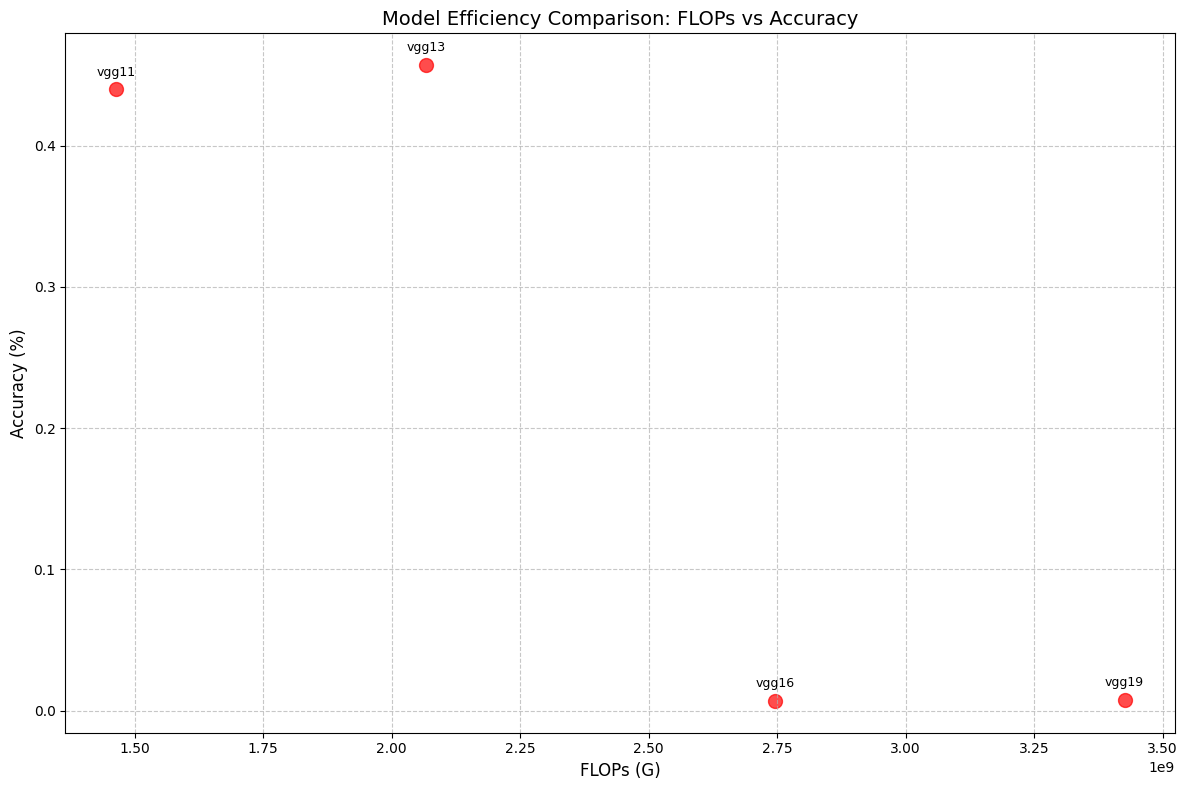

In [20]:
import matplotlib.pyplot as plt

def plot_flops_acc(flops_data_dict, save_name, figsize=(12, 8)):
    """
    FLOPs vs Accuracy 플롯 생성 함수
    
    Args:
        flops_data_dict (dict): {model_name: (accuracy, flops)} 형태의 딕셔너리
        figsize (tuple): 그림 크기 (가로, 세로)
    """
    plt.figure(figsize=figsize)
    
    # 데이터 추출
    model_names = list(flops_data_dict.keys())
    accuracies = [v[0] for v in flops_data_dict.values()]
    flops = [v[1] for v in flops_data_dict.values()]
    
    # 산점도 플롯
    plt.scatter(flops, accuracies, s=100, alpha=0.7, color="red")
    
    # 각 점에 모델 이름 주석 추가
    for name, x, y in zip(model_names, flops, accuracies):
        plt.annotate(name, (x, y), 
                     textcoords="offset points",
                     xytext=(0,10),
                     ha='center',
                     fontsize=9)
    
    # 축 레이블 및 제목
    plt.xlabel('FLOPs (G)', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title('Model Efficiency Comparison: FLOPs vs Accuracy', fontsize=14)
    
    # 그리드 및 레이아웃 조정
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(save_name)
    plt.show()
    

plot_flops_acc(flops_data_dict_2, save_name="tmp2.png")

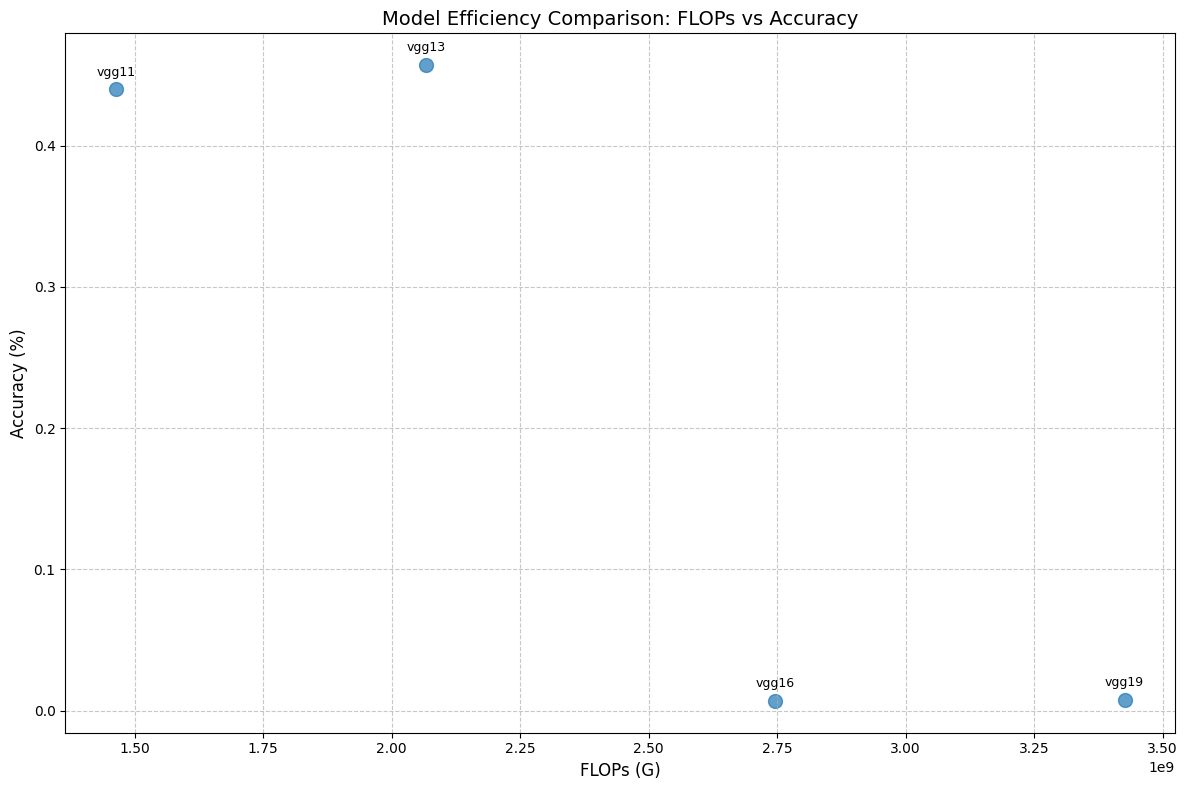

In [18]:
plot_flops_acc(flops_data_dict_2)